In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

Note: in all codes here we use the same random F as in the simulation

# Averages on the fly: Parallel implementation

In [2]:
from scipy.stats import skew
from scipy.stats import kurtosis

def L96_parallel_RK4_avgOnTheFly(x0, s=0.0, dt=0.01, N=10000, rand_seed=123):
    """
    Vectorized RK4 + Euler–Maruyama integration of the Lorenz–96 system 
    with ensemble averaging on the fly.

    dx_i/dt = (x_{i+1} - x_{i-2})*x_{i-1} - x_i + F + s*dW_i

    Args:
        x0 : np.ndarray, shape (Nens, K)
            Initial conditions for all ensemble members.
        F : float
            Constant forcing term.
        s : float
            Noise amplitude.
        dt : float
            Time step.
        N : int
            Number of integration steps.
        rand_seed : int
            Random seed for reproducibility.

    Returns:
        avg_x : np.ndarray, shape (N, K)
            Ensemble mean at each time step.
        var_x : np.ndarray, shape (N, K)
            Ensemble variance at each time step.
    """
    rng = np.random.default_rng(rand_seed)
    Nens, K = x0.shape
    x = x0.copy()

    avg_x = np.zeros((N, K))
    var_x = np.zeros((N, K))
    sqrt_dt = np.sqrt(dt)

    F = np.array([ 6.1087865 , 12.32213349, 28.87925261, 17.93974419, 25.202309  ,
       21.77103791,  9.63536354, 21.4195222 , 12.83404549, 12.77610884,
       16.97167319,  4.        , 27.92166104,  9.28910325, 26.0026942 ,
       17.36321124, 31.3203308 ,  9.40030586, 12.88205144, 19.37769127])

    def f_det(x):
        """Vectorized deterministic Lorenz-96 tendency."""
        return (np.roll(x, -1, axis=1) - np.roll(x, 2, axis=1)) * np.roll(x, 1, axis=1) - x + F

    for t in range(N):
        # Compute ensemble mean/variance on the fly
        avg_x[t] = np.mean(x, axis=0)
        var_x[t] = np.var(x, axis=0)

        # Noise term
        wiener = rng.normal(0, 1, (Nens, K)) * sqrt_dt

        # RK4 for deterministic part (fully vectorized)
        k1 = f_det(x)
        k2 = f_det(x + 0.5 * dt * k1)
        k3 = f_det(x + 0.5 * dt * k2)
        k4 = f_det(x + dt * k3)

        dx_det = (k1 + 2*k2 + 2*k3 + k4) / 6

        # Update state: deterministic RK4 + stochastic Euler-Maruyama
        x = x + dt * dx_det + s * wiener

    return avg_x, var_x

In [3]:
trajectory = np.load('./results/L96_orbit.npy')

In [4]:
sigmas = np.std(trajectory,0)
sigmas

array([7.56051603, 7.28051617, 8.04130866, 8.35971386, 7.84499008,
       7.89019773, 7.39104772, 7.12083506, 7.16999896, 6.80425621,
       7.15420437, 7.16572948, 7.54664653, 7.91313966, 7.92351437,
       7.90953419, 7.94376796, 7.66738348, 6.98937564, 7.14131851])

In [5]:
del trajectory # free some memory

In [6]:
import numpy as np

def L96_parallel_RK4_avgOnTheFly_with_Gaussian(x0, sigma_10, mu=10, width=5.0, s=0.0, dt=0.01, N=10000, rand_seed=123):
    """
    Computes the ensemble average response to a static Gaussian forcing.
    The forcing peaks at index `mu`, with spatial width `width`, and amplitude `sigma_10`.
    """
    rng = np.random.default_rng(rand_seed)
    Nens, K = x0.shape
    x = x0.copy()

    avg_x = np.zeros((N, K))
    var_x = np.zeros((N, K))
    sqrt_dt = np.sqrt(dt)

    # Base forcing vector
    F_base = np.array([ 6.1087865 , 12.32213349, 28.87925261, 17.93974419, 25.202309  ,
                        21.77103791,  9.63536354, 21.4195222 , 12.83404549, 12.77610884,
                        16.97167319,  4.        , 27.92166104,  9.28910325, 26.0026942 ,
                        17.36321124, 31.3203308 ,  9.40030586, 12.88205144, 19.37769127])

    # 1. Calculate periodic distance from the peak (mu)
    k_indices = np.arange(K)
    dist = np.minimum(np.abs(k_indices - mu), K - np.abs(k_indices - mu))
    
    # 2. Build the Gaussian perturbation vector
    delta_F = sigma_10 * np.exp(-0.5 * (dist / width)**2)
    
    # 3. Add to the base forcing
    F_perturbed = F_base + delta_F

    def f_det(x_in, forcing):
        """Vectorized deterministic Lorenz-96 tendency with custom forcing."""
        return (np.roll(x_in, -1, axis=1) - np.roll(x_in, 2, axis=1)) * np.roll(x_in, 1, axis=1) - x_in + forcing

    for t in range(N):
        # Stats on the fly
        avg_x[t] = np.mean(x, axis=0)
        var_x[t] = np.var(x, axis=0)

        wiener = rng.normal(0, 1, (Nens, K)) * sqrt_dt

        # RK4 using the perturbed Gaussian forcing vector
        k1 = f_det(x, F_perturbed)
        k2 = f_det(x + 0.5 * dt * k1, F_perturbed)
        k3 = f_det(x + 0.5 * dt * k2, F_perturbed)
        k4 = f_det(x + dt * k3, F_perturbed)

        # Update
        x = x + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4) + s * wiener

    return avg_x, var_x

# Forcing

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/state/partition1/job-4100935/ipykernel_943253/3254805611.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"Periodic Gaussian Forcing ($\mu={mu}$, $w={width}$, $A=\sigma_{{10}}$)", fontsize=14)
/state/partition1/job-4100935/ipykernel_943253/3254805611.py:33: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Periodic Gaussian Forcing ($\mu={mu}$, $w={width}$, $A=\sigma_{{10}}$)", fontsize=14)


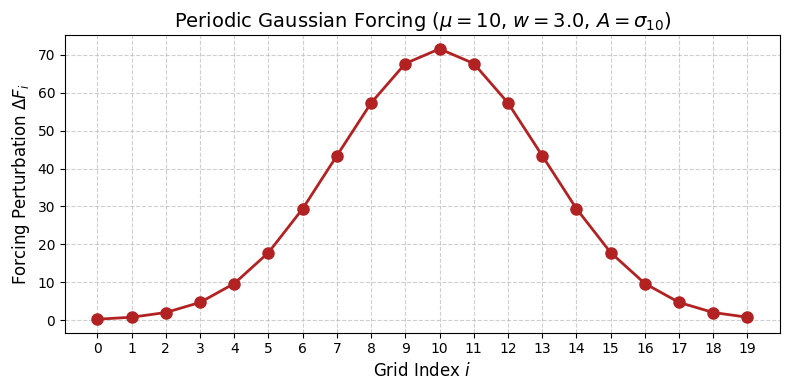

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid and parameters
K = 20
mu = 10
width = 3.0
sigma_10 = 10*sigmas[10]  # Replace this with your actual computed standard deviation

# 1. Calculate periodic distance from the peak
k_indices = np.arange(K)
dist = np.minimum(np.abs(k_indices - mu), K - np.abs(k_indices - mu))

# 1. The Standard Gaussian (Flawed for a periodic ring)
dist_standard = np.abs(k_indices - mu)
delta_F_standard = sigma_10 * np.exp(-0.5 * (dist_standard / width)**2)

# 2. Build the Gaussian perturbation vector
delta_F = sigma_10 * np.exp(-0.5 * (dist / width)**2)

# 3. Plotting
fig, ax = plt.subplots(figsize=(8, 4))

# Plot with markers to show the discrete L96 sites
ax.plot(k_indices, delta_F, marker='o', linestyle='-', color='firebrick', linewidth=2, markersize=8)
#ax.plot(k_indices, delta_F_standard, marker='x', linestyle='-', color='blue', linewidth=2, markersize=8)

#ax.fill_between(k_indices, delta_F, color='firebrick', alpha=0.2)

# Formatting
ax.set_xlabel("Grid Index $i$", fontsize=12)
ax.set_ylabel(r"Forcing Perturbation $\Delta F_i$", fontsize=12)
ax.set_title(f"Periodic Gaussian Forcing ($\mu={mu}$, $w={width}$, $A=\sigma_{{10}}$)", fontsize=14)
ax.set_xticks(k_indices)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Simulate

In [8]:
long_trajectory = np.load('./results/L96_orbit.npy')#[0:10**7]
sigmas = np.std(long_trajectory,0)
sigmas

array([7.56051603, 7.28051617, 8.04130866, 8.35971386, 7.84499008,
       7.89019773, 7.39104772, 7.12083506, 7.16999896, 6.80425621,
       7.15420437, 7.16572948, 7.54664653, 7.91313966, 7.92351437,
       7.90953419, 7.94376796, 7.66738348, 6.98937564, 7.14131851])

In [9]:
sigmas[10]

np.float64(7.1542043748496)

In [10]:
%%time
period_long = 500 # This is Model Time Unit (MTI) = 50

# Number of ensemble members
N_ens = 10**6 #10000000
s = 5
dt = 0.01

'''
Let us sample initial conditions directly from the attractor. 
To do so, we consider a long integration of the system and random sample 
an ensemble of initial conditions from it
'''

# We apply on i = 10
sigma_10 = 10*sigmas[10]

# Load the long trajectory, but keep only the first 10^7 points
long_trajectory = np.load('./results/L96_orbit.npy')#[0:10**7]

# Consider N_ens initial conditions
# I have N_ens indices going from 0 to the length of the trajectory
idx = np.random.randint(0, len(long_trajectory),N_ens)

# We here considering these initial conditions equispaces
#n_steps = long_trajectory.shape[0]
# Equally spaced indices between 0 and n_steps-1
#idx = np.linspace(0, n_steps - 1, N_ens, dtype=int)
x_0 = long_trajectory[idx]

del long_trajectory # free some memory

########## Ensemble of control simulations on the attractor

# Generate a random seed (or set it manually for reproducibility)
rand_seed_c = np.random.randint(0, 2**32 - 1)  # Random seed
# 1. Run Control
C_avg, C_var = L96_parallel_RK4_avgOnTheFly(x_0, 
                                            s=s, 
                                            dt=dt, 
                                            N=period_long, 
                                            rand_seed=rand_seed_c)

########## Ensemble of perturbed simulations on the attractor
P_avg, P_var = L96_parallel_RK4_avgOnTheFly_with_Gaussian(x_0, 
                                           sigma_10, 
                                           mu=10, 
                                           width=3.0, 
                                           s=s, 
                                           dt=dt, 
                                           N=period_long, 
                                           rand_seed=rand_seed_c)

# Note, I am using the same seed as the control run

# Response in the mean
R_mean = (P_avg-C_avg)
R_var = (P_var-C_var)

CPU times: user 18min 38s, sys: 6min 22s, total: 25min
Wall time: 25min 5s


In [12]:
# Save the control and perturbed ensemble
np.save('./results_responses_Gaussian/response_mean_x_'+str(10)+'-10Sigma.npy',R_mean)
np.save('./results_responses_Gaussian/response_var_x_'+str(10)+'-10Sigma.npy',R_var)

Text(0.5, 1.0, '$u_i(t)$')

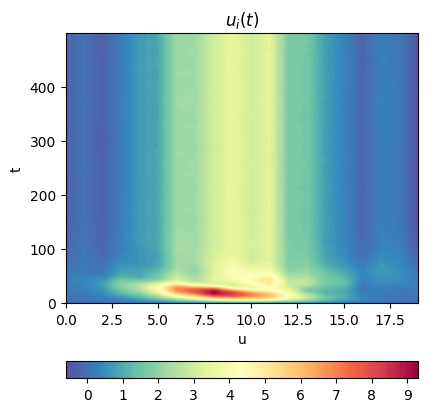

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1,2,2)
plt.contourf(R_mean,levels=100, cmap='Spectral_r')
#plt.imshow(R_mean,cmap='Spectral_r')
plt.colorbar(orientation="horizontal")
plt.xlabel("u")
plt.ylabel("t")
plt.title("$u_i(t)$")

Text(0.5, 1.0, '$u_i(t)$')

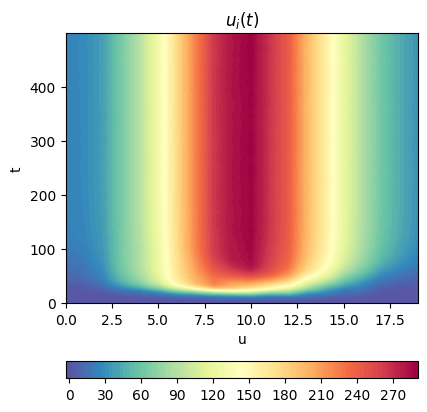

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1,2,2)
plt.contourf(R_var,levels=100, cmap='Spectral_r')
#plt.imshow(R_mean,cmap='Spectral_r')
plt.colorbar(orientation="horizontal")
plt.xlabel("u")
plt.ylabel("t")
plt.title("$u_i(t)$")